<a href="https://colab.research.google.com/github/61liuyii/garbage_classification/blob/main/%E6%AC%A2%E8%BF%8E%E4%BD%BF%E7%94%A8_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [6]:
!unzip /content/drive/MyDrive/archive.zip -d /content/archive


流式输出内容被截断，只能显示最后 5000 行内容。
  inflating: /content/archive/Garbage classification/Garbage classification/cardboard/cardboard152.jpg  
  inflating: /content/archive/Garbage classification/Garbage classification/cardboard/cardboard153.jpg  
  inflating: /content/archive/Garbage classification/Garbage classification/cardboard/cardboard154.jpg  
  inflating: /content/archive/Garbage classification/Garbage classification/cardboard/cardboard155.jpg  
  inflating: /content/archive/Garbage classification/Garbage classification/cardboard/cardboard156.jpg  
  inflating: /content/archive/Garbage classification/Garbage classification/cardboard/cardboard157.jpg  
  inflating: /content/archive/Garbage classification/Garbage classification/cardboard/cardboard158.jpg  
  inflating: /content/archive/Garbage classification/Garbage classification/cardboard/cardboard159.jpg  
  inflating: /content/archive/Garbage classification/Garbage classification/cardboard/cardboard16.jpg  
  inflating: /content/archive

In [7]:
data_dir = "/content/archive/Garbage classification"
print(os.listdir(data_dir))


['Garbage classification']


In [8]:
data_dir = "/content/archive/Garbage classification/Garbage classification"
print(os.listdir(data_dir))


['cardboard', 'metal', 'glass', 'plastic', 'paper', 'trash']


In [9]:
import os
for root, dirs, files in os.walk("/content/archive"):
    print(root, dirs, files)


/content/archive ['Garbage classification', 'garbage classification'] ['one-indexed-files-notrash_test.txt', 'one-indexed-files-notrash_train.txt', 'zero-indexed-files.txt', 'one-indexed-files-notrash_val.txt', 'one-indexed-files.txt']
/content/archive/Garbage classification ['Garbage classification'] []
/content/archive/Garbage classification/Garbage classification ['cardboard', 'metal', 'glass', 'plastic', 'paper', 'trash'] []
/content/archive/Garbage classification/Garbage classification/cardboard [] ['cardboard60.jpg', 'cardboard395.jpg', 'cardboard288.jpg', 'cardboard129.jpg', 'cardboard188.jpg', 'cardboard324.jpg', 'cardboard122.jpg', 'cardboard173.jpg', 'cardboard215.jpg', 'cardboard153.jpg', 'cardboard311.jpg', 'cardboard286.jpg', 'cardboard402.jpg', 'cardboard116.jpg', 'cardboard161.jpg', 'cardboard289.jpg', 'cardboard334.jpg', 'cardboard21.jpg', 'cardboard222.jpg', 'cardboard366.jpg', 'cardboard43.jpg', 'cardboard58.jpg', 'cardboard176.jpg', 'cardboard239.jpg', 'cardboard68.j

In [10]:
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

# 定义预处理
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# 加载数据集
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 划分训练集和验证集
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("类别:", dataset.classes)
print("训练集大小:", len(train_dataset))
print("验证集大小:", len(val_dataset))


类别: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
训练集大小: 2021
验证集大小: 506


In [13]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [16]:
import os
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ==================== 1. 设置正确路径（已按你解压位置填写） ====================
data_dir = "/content/archive/Garbage classification/Garbage classification"

# 自动验证路径是否包含6个类别文件夹
if os.path.exists(data_dir):
    classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    print(f"✅ 路径正确！找到 {len(classes)} 个类别文件夹：{classes}")
else:
    print("❌ 路径错误，请把下面内容复制发给我")
    print(os.listdir("/content/archive/Garbage classification"))

# ==================== 2. 数据预处理（推荐迁移学习标准） ====================
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==================== 3. 加载数据集 ====================
dataset = datasets.ImageFolder(root=data_dir, transform=None)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# 分别应用 transform
train_dataset.dataset.transform = train_transform
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("\n✅ 数据集加载成功！")
print("类别列表:", dataset.classes)
print("总图片数:", len(dataset))
print("训练集大小:", len(train_dataset))
print("验证集大小:", len(val_dataset))

✅ 路径正确！找到 6 个类别文件夹：['cardboard', 'metal', 'glass', 'plastic', 'paper', 'trash']

✅ 数据集加载成功！
类别列表: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
总图片数: 2527
训练集大小: 2021
验证集大小: 506


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


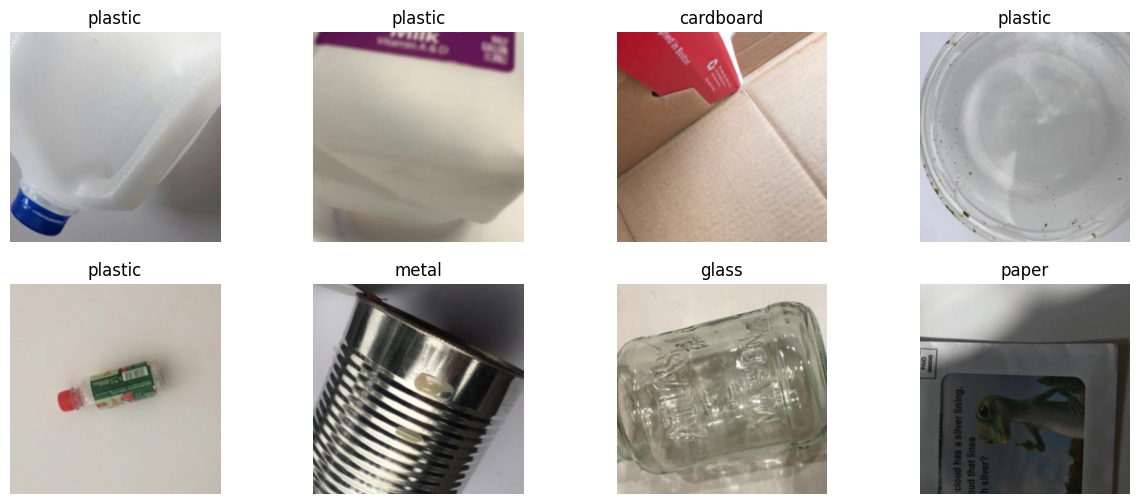

In [17]:
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.axis('off')

# 取一批图片显示
dataiter = iter(train_loader)
images, labels = next(dataiter)

plt.figure(figsize=(15, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow(images[i])
    plt.title(dataset.classes[labels[i]])
plt.show()

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
